## Linear Regression


### "I want to predict Y using X"

- Linear regression is a supervised machine learning algorithm that aims to predict a continuous target variable (y) based on a set of independent variables (X). 

- It finds a linear relationship between the input variables and the output variable by fitting a straight line (or plane) to the training data points. 

- The algorithm learns the optimal coefficients for the line by minimizing the sum of squared differences between the predicted and actual values. 

- When a prediction is needed, the algorithm uses the learned coefficients to estimate the target variable based on the given input variables, providing a continuous numerical prediction.

Let's say you have a set of Xs (predictors) and y (target).

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/features-to-target.png" width="500" alt="features-to-target">

Assuming the relationship between each $x$ and $y$ is linear, the relationship between the predictors $X$ and the target $y$ can be expressed as:

$$y_i = \beta_0 + \beta_1 x_{1,i} + \beta_2 x_{2,i} + \beta_3 x_{3,i} + \cdots + \beta_p x_{p,i} + \epsilon_i \qquad \text{for } i = 1, \ldots, n$$

where, for the $i$-th observation:
- $y_i$ is the observed target value
- $x_{j,i}$ is the value of the $j$-th predictor
- $\beta_0$ is the intercept and $\beta_j$ is the coefficient of the $j$-th predictor
- $\epsilon_i$ is the error term
- $n$ is the number of observations and $p$ is the number of predictors

What we want here is to find a function that fits $x$ to $y$ well.

Once we have the coefficients, we approximate $y$ by dropping the unobservable error term $\epsilon_i$. This gives the **predicted** value $\hat y_i$:

$$\hat y_i = \hat\beta_0 + \hat\beta_1 x_{1,i} + \hat\beta_2 x_{2,i} + \hat\beta_3 x_{3,i} + \cdots + \hat\beta_p x_{p,i} \qquad \text{for } i = 1, \ldots, n$$

where, for the $i$-th observation:
- $\hat y_i$ is the predicted target value
- $\hat\beta_0$ is the **estimated** intercept and $\hat\beta_j$ is the **estimated** coefficient of the $j$-th predictor

The hat ($\hat{\ }$) marks a quantity **estimated from the data** — we never know the true $\beta_j$, only our estimates $\hat\beta_j$, so predictions are built from the estimates.

----------

### One predictor case

With a single predictor ($p = 1$), the feature subscript is no longer needed and the model reduces to a straight line:

$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i \qquad \text{for } i = 1, \ldots, n$$

and its prediction is:

$$\hat y_i = \hat\beta_0 + \hat\beta_1 x_i \qquad \text{for } i = 1, \ldots, n$$

where, for the $i$-th observation:
- $x_i$ is the single predictor value and $y_i$ is the observed target
- $\beta_0$ is the intercept (where the line crosses the $y$-axis)
- $\beta_1$ is the slope (how much $\hat y$ changes per one-unit increase in $x$)
- $\epsilon_i$ is the error term

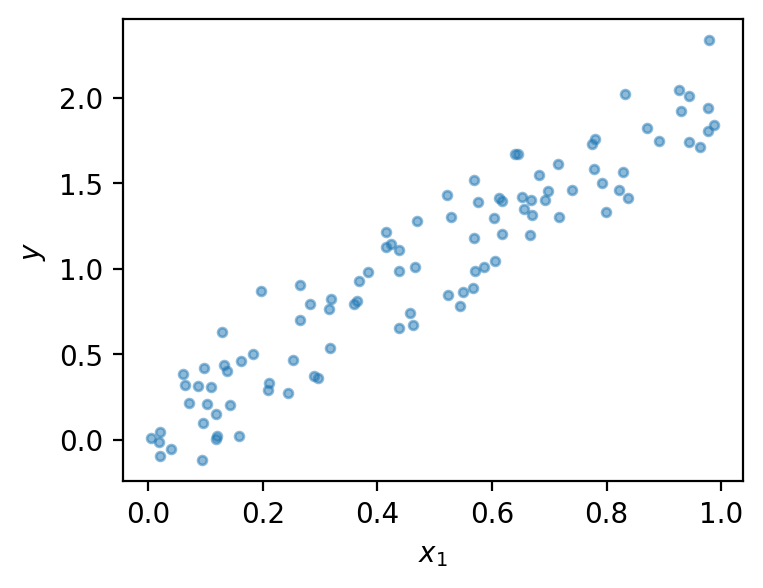

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)  # for reproducibility

fig, ax = plt.subplots(figsize=(4, 3), dpi=200)

x1 = np.random.uniform(0, 1, 100)
y = x1 * 2 + np.random.normal(0, 0.2, 100)  # y = 2*x1 + noise
ax.scatter(x1, y, alpha=0.5, s=10)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$y$")

# OLS regression line (least-squares fit): np.polyfit(x, y, 1) returns [slope, intercept]
plot_line = False

if plot_line:
    slope, intercept = np.polyfit(x1, y, 1)
    xs = np.array([x1.min(), x1.max()])
    ax.plot(xs, slope * xs + intercept, color="red", lw=1.5)

- The image above shows a linear regression with **1 input variable and 1 output variable** — the simplest case.

- In real-world problems there can be as many input variables as needed, each with its own coefficient.

For example, predicting a building's energy consumption:

$$\text{energy} = \beta_0 + \beta_1\,\text{occupancy} + \beta_2\,\text{climate} + \beta_3\,\text{energy price} + \beta_4\,\text{building age} + \beta_5\,\text{mean setpoint} + \cdots$$

### Begin Exercise - Housing Price Prediction

Let's try this regression analysis with an example of prediction housing prices. 

#### Import libraries and initialize random generator

In [2]:
import pandas as pd
import numpy as np
np.random.seed(0)

#### Read data from CSV
We will use the Boston Housing dataset. This dataset consists of 13 input features related to housing prices in Boston, such as crime rate and average number of rooms. We are going predict housing price based on 13 features.

<!-- <img src="https://raw.githubusercontent.com/MLcmore2023/MLcmore2023/main/.images/linear_regression2.png" alt="image" width=90%> -->

The 14 columns in the dataset:

1. **CRIM** — per capita crime rate by town
2. **ZN** — proportion of residential land zoned for lots over 25,000 sq.ft.
3. **INDUS** — proportion of non-retail business acres per town
4. **CHAS** — Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5. **NOX** — nitric oxides concentration (parts per 10 million)
6. **RM** — average number of rooms per dwelling
7. **AGE** — proportion of owner-occupied units built prior to 1940
8. **DIS** — weighted distances to five Boston employment centres
9. **RAD** — index of accessibility to radial highways
10. **TAX** — full-value property-tax rate per \$10,000
11. **PTRATIO** — pupil-teacher ratio by town
12. **B** — 1000(Bk − 0.63)^2 where Bk is the proportion of blacks by town
13. **LSTAT** — % lower status of the population
14. **MEDV** — median value of owner-occupied homes in \$1000's *(the target, `y`)*

In [3]:
dataset = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")

print("The number of rows and columns in the dataset: {} rows, {} columns".format(*dataset.shape))

display(dataset.head())

The number of rows and columns in the dataset: 506 rows, 14 columns


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


### You may check how the data look like first before model fitting (in many data analysis problem) 

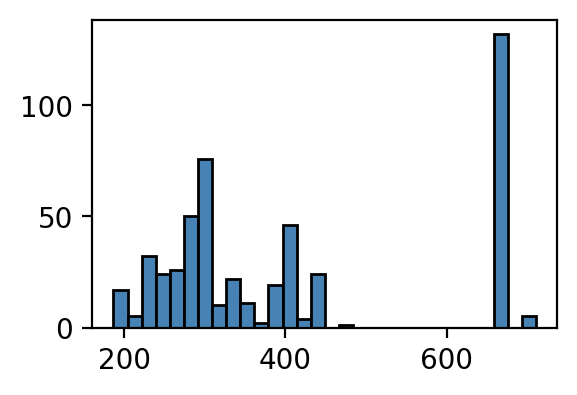

In [4]:
fig, ax = plt.subplots(figsize=(3, 2), dpi=200)

# You can try different columns in the dataset to see how the distribution changes
# crim, zn, indus, chas, nox, rm, age, dis, rad, tax, ptratio, b, lstat, medv

ax.hist(dataset['tax'], bins=30, color='steelblue', edgecolor='black');

### We are going to use the dataframe to fit a function

#### Linear regression coefficients
Using the equation from the beginning of this tutorial, we want to find a set of coefficients (β0,β1,β2...) such that the errors are as small as possible.

<!-- $$y_i = \beta_0 + \beta_1 x_i + \epsilon_i \qquad \text{for } i = 1, \ldots, n$$ -->
$$\hat y_i = \hat\beta_0 + \hat\beta_1 x_{1,i} + \hat\beta_2 x_{2,i} + \hat\beta_3 x_{3,i} + \cdots + \hat\beta_p x_{p,i} \qquad \text{for } i = 1, \ldots, n$$

The above can be written in matrix form:


$$
\underbrace{\begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}}_{Y}
=
\underbrace{\begin{bmatrix}
1 & x_{1,1} & \cdots & x_{p,1} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & \cdots & x_{p,n}
\end{bmatrix}}_{X}
\underbrace{\begin{bmatrix} \beta_0 \\ \vdots \\ \beta_p \end{bmatrix}}_{\beta}
+
\underbrace{\begin{bmatrix} \varepsilon_1 \\ \vdots \\ \varepsilon_n \end{bmatrix}}_{\varepsilon}
$$


which is written compactly as:

$$Y = X\beta + \varepsilon$$


In [5]:
y = dataset["medv"].values # the output variable is the median price
dataset = dataset.drop("medv", axis=1)

In [6]:
# put the columns of ones into the front of the dataset
print("before:")
display(dataset.head())

before:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


### There is no intercept column. So...

In [7]:
dataset_step1 = dataset.copy()
dataset_step1.insert(0, 'intercept', 1)
print("after:")
display(dataset_step1.head())
print("It becomes a matrix X of shape: {}".format(dataset_step1.shape))

after:


,intercept,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,1,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,1,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,1,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


It becomes a matrix X of shape: (506, 14)


$$
\underbrace{\begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}}_{Y}
=
\underbrace{\begin{bmatrix}
1 & x_{1,1} & \cdots & x_{p,1} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & \cdots & x_{p,n}
\end{bmatrix}}_{X}
\underbrace{\begin{bmatrix} \beta_0 \\ \vdots \\ \beta_p \end{bmatrix}}_{\beta}
+
\underbrace{\begin{bmatrix} \varepsilon_1 \\ \vdots \\ \varepsilon_n \end{bmatrix}}_{\varepsilon}
$$


### Next step is to find the vector beta

#### Multicollinearity

In the laset figure, we drew the relationships between Xs and y are as follows:

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/features-to-target.png" width="500" alt="features-to-target">


We haven't drawn any relationships between Xs. But actually in the real-world, Xs may have inter-relationships (correlated). If both of them provides largely the same information, we may want to omit one 

As an example, imagine you are trying to predict ice cream sales in a Disney Land with the amount of people in the park. Now, you are given a new variable, the amount of tickets sold today. Assuming every tourist have a ticket, the amount of tickets sold should be 100% related to the amount of people in the park. This variable is useless, because it does not give any new information.

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/multicollinearity.png" width="470" alt="multicollinearity">


Addressing multicollinearity (colinearity) is an important consideration when performing linear regression. Multicollinearity occurs when two or more predictor variables in a regression model are highly correlated with each other. It can lead to unstable and unreliable coefficient estimates, making it difficult to interpret the impact of individual predictors on the target variable.

To address multicollinearity, we can do any of the following:
- Removing one of the highly correlated variables.
- Transforming variables (e.g., using principal component analysis or dimensionality reduction techniques).
- Combining correlated variables into a single variable.

### Let's check multicolinearity and remove some variables if needed.

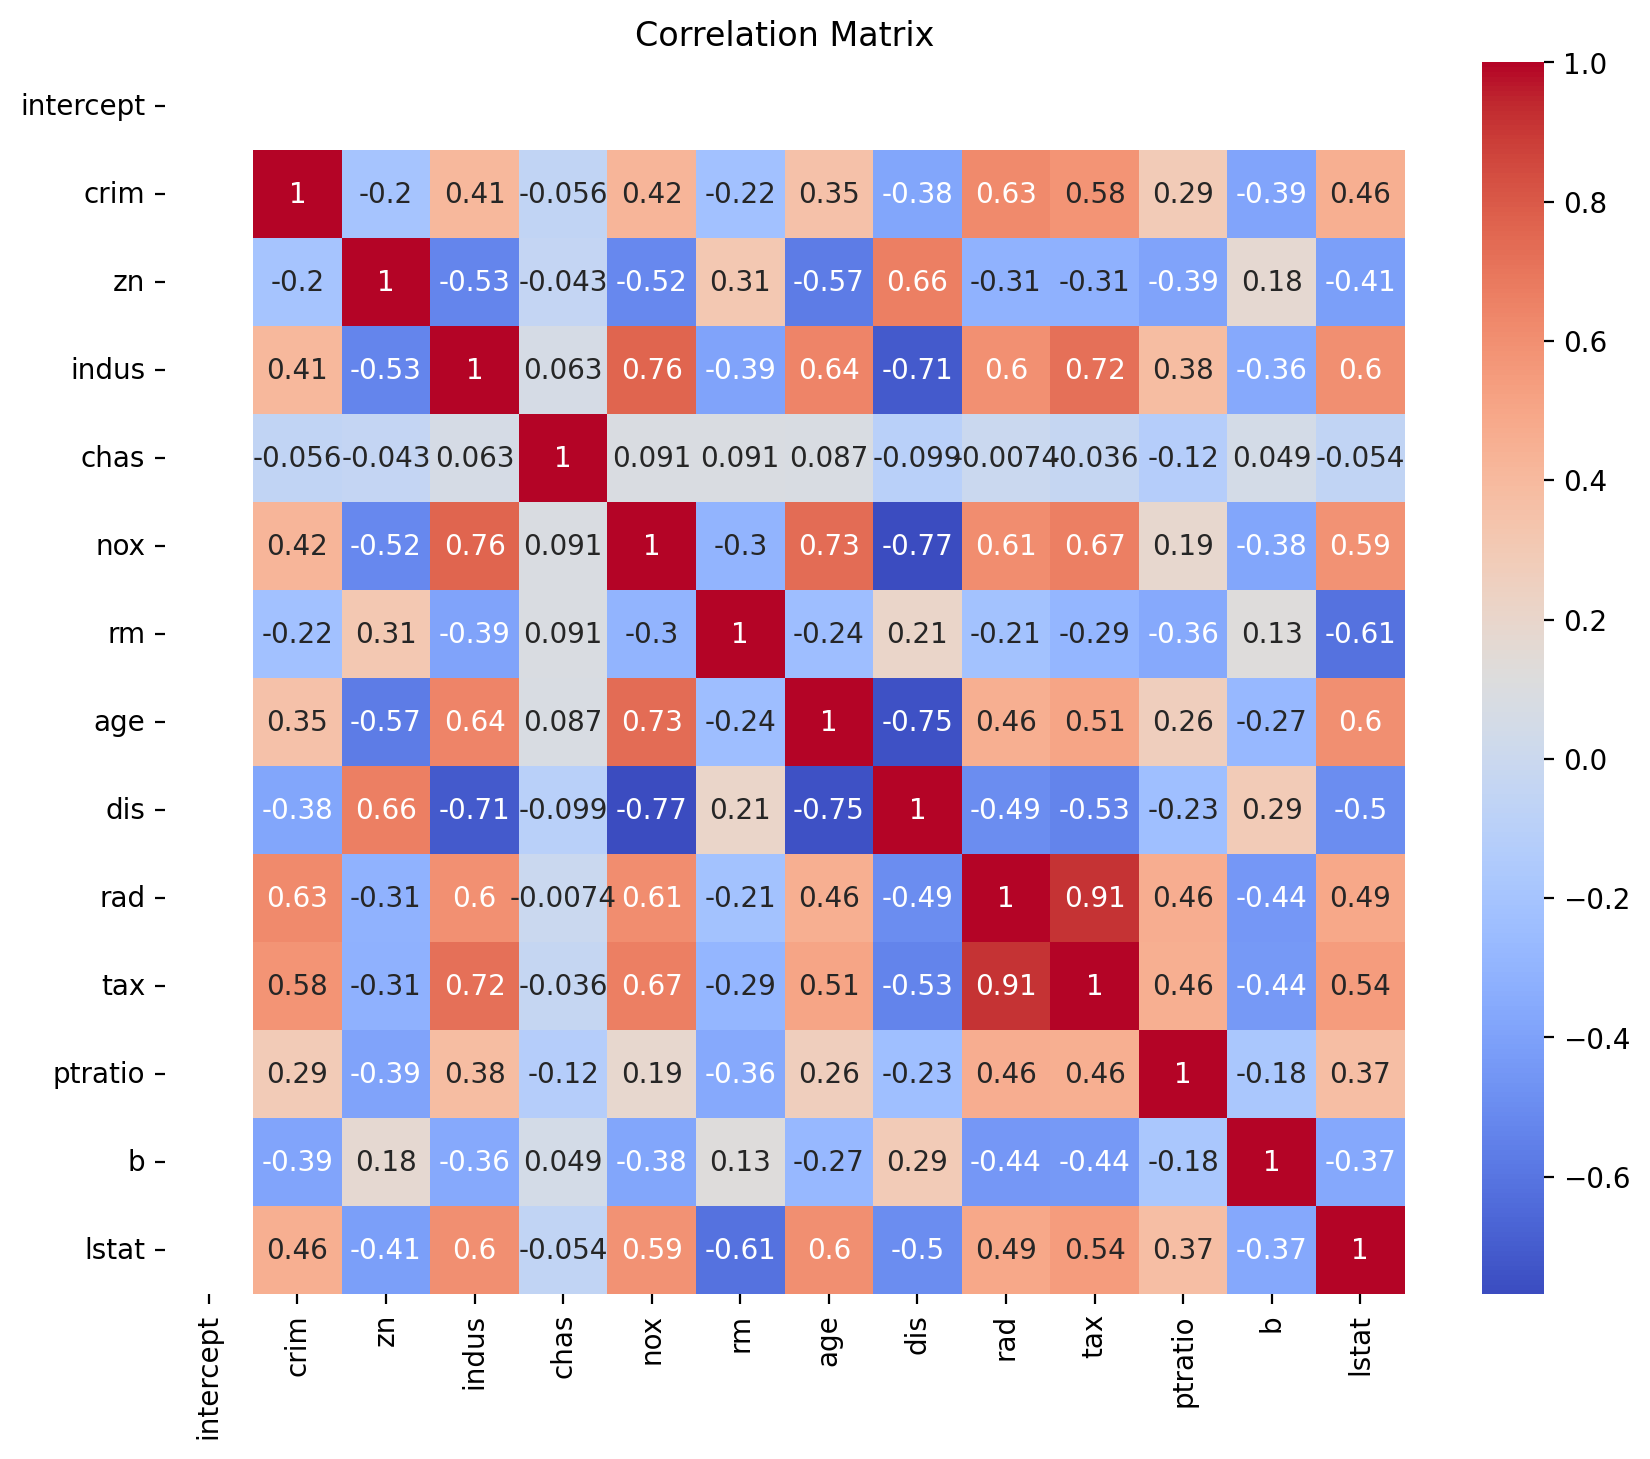

In [8]:
#calculate correlations
correlation_matrix = dataset_step1.corr()

#graph heat map
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", ax = ax)
ax.set_title("Correlation Matrix");

we found that `tax` and `rad` are highly correlated ( r = -0.91 ). We can drop one of them (`tax` is chose arbitrarily)

In [9]:
dataset_step2 = dataset_step1.copy()
dataset_step2 = dataset_step2.drop('tax', axis=1)

#### Extract features (independent variables) and target variable

In [10]:
X = dataset_step2.values # the input variable is all columns except the median price
print(X[0:5], "X shape = {}".format(X.shape))
print(y[0:5], "y shape = {}".format(y.shape))

[[1.0000e+00 6.3200e-03 1.8000e+01 2.3100e+00 0.0000e+00 5.3800e-01
  6.5750e+00 6.5200e+01 4.0900e+00 1.0000e+00 1.5300e+01 3.9690e+02
  4.9800e+00]
 [1.0000e+00 2.7310e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01
  6.4210e+00 7.8900e+01 4.9671e+00 2.0000e+00 1.7800e+01 3.9690e+02
  9.1400e+00]
 [1.0000e+00 2.7290e-02 0.0000e+00 7.0700e+00 0.0000e+00 4.6900e-01
  7.1850e+00 6.1100e+01 4.9671e+00 2.0000e+00 1.7800e+01 3.9283e+02
  4.0300e+00]
 [1.0000e+00 3.2370e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01
  6.9980e+00 4.5800e+01 6.0622e+00 3.0000e+00 1.8700e+01 3.9463e+02
  2.9400e+00]
 [1.0000e+00 6.9050e-02 0.0000e+00 2.1800e+00 0.0000e+00 4.5800e-01
  7.1470e+00 5.4200e+01 6.0622e+00 3.0000e+00 1.8700e+01 3.9690e+02
  5.3300e+00]] X shape = (506, 13)
[24.  21.6 34.7 33.4 36.2] y shape = (506,)


#### Splitting training and testing set

In [11]:
from sklearn.model_selection import train_test_split
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [12]:
X_train

array([[1.0000e+00, 3.5809e-01, 0.0000e+00, ..., 1.7400e+01, 3.9170e+02,
        9.7100e+00],
       [1.0000e+00, 1.5876e-01, 0.0000e+00, ..., 1.9200e+01, 3.7694e+02,
        9.8800e+00],
       [1.0000e+00, 1.1329e-01, 3.0000e+01, ..., 1.6600e+01, 3.9125e+02,
        1.1380e+01],
       ...,
       [1.0000e+00, 1.5098e-01, 0.0000e+00, ..., 1.7800e+01, 3.9451e+02,
        1.0300e+01],
       [1.0000e+00, 2.2927e-01, 0.0000e+00, ..., 1.7900e+01, 3.9274e+02,
        1.8800e+01],
       [1.0000e+00, 1.3914e-01, 0.0000e+00, ..., 1.6600e+01, 3.9690e+02,
        1.4690e+01]], shape=(404, 13))

$$
\underbrace{\begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}}_{Y}
=
\underbrace{\begin{bmatrix}
1 & x_{1,1} & \cdots & x_{p,1} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & \cdots & x_{p,n}
\end{bmatrix}}_{X}
\underbrace{\begin{bmatrix} \beta_0 \\ \vdots \\ \beta_p \end{bmatrix}}_{\beta}
+
\underbrace{\begin{bmatrix} \varepsilon_1 \\ \vdots \\ \varepsilon_n \end{bmatrix}}_{\varepsilon}
$$


### Then, we want to estimate the coefficients of variables - OLS

#### Least square matrix equation


We pick the coefficients $\beta$ to **minimize the sum of squared errors** between the observed $Y$ and the fitted $X\beta$.

**1. Residual vector** — for a candidate $\beta$:
$$e = Y - X\beta$$

**2. Objective** — the sum of squared errors:
$$S(\beta) = e^T e = (Y - X\beta)^T(Y - X\beta)$$

**3. Expand** (using that $\beta^T X^T Y = Y^T X\beta$, since a scalar equals its own transpose):
$$S(\beta) = Y^T Y - 2\,\beta^T X^T Y + \beta^T X^T X\beta$$

**4. Set the gradient to zero** (minimize over $\beta$):
$$\frac{\partial S}{\partial \beta} = -2X^T Y + 2X^T X\beta = 0$$

**5. Normal equations:**
$$X^T X\beta = X^T Y$$

**6. Solve** (assuming $X^T X$ is invertible), which gives the Ordinary Least Square (OLS) estimator — the hat marks that it is estimated from data:
$$\hat\beta = \begin{bmatrix} \hat\beta_0 \\ \hat\beta_1 \\ \vdots \\ \hat\beta_p \end{bmatrix} = (X^T X)^{-1}X^T Y$$

In [13]:
# Calculating the coefficients using the normal equation: (X^T * X)^(-1) * X^T * y
coefficients = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
print(coefficients)

[ 3.64584087e+01 -1.18200507e-01  3.59488934e-02 -7.66645109e-02
  2.63740998e+00 -1.69093435e+01  3.80647510e+00 -4.04861347e-03
 -1.38508521e+00  9.01668899e-02 -1.07495082e+00  8.18988708e-03
 -4.90062785e-01]


$$
\underbrace{\begin{bmatrix} y_1 \\ \vdots \\ y_n \end{bmatrix}}_{Y}
=
\underbrace{\begin{bmatrix}
1 & x_{1,1} & \cdots & x_{p,1} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{1,n} & \cdots & x_{p,n}
\end{bmatrix}}_{X}
\underbrace{\begin{bmatrix} \hat\beta_0 \\ \vdots \\ \hat\beta_p \end{bmatrix}}_{\hat\beta}
$$


In [14]:
# Making predictions for the test set
y_prediction = X_test @ coefficients
print(y_prediction)

[26.90774061 23.72503516 28.84409005 12.04670157 22.10478459 19.28621142
 20.55495817 20.59454076 18.73353634 20.61173187  5.15075298 16.47215093
 17.02753739  5.46313433 40.52082246 33.21339021 22.57916358 37.74487633
 31.15748433 22.96940716 24.60024602 24.73799856 21.28593875 29.81452906
 22.03597505 10.00367352 17.64743991 18.11565979 36.28213227 21.97121278
 18.34798542 17.74866251 19.91579293 23.92197206 29.34539228 19.4462219
 11.15761024 24.81858884 17.65244166 15.56477699 25.82543834 20.50102308
 24.30540251 15.59739888 25.47710877 25.04236625 19.68554463 23.08614817
  9.84940417 25.027925   21.12330885 17.89006251 24.20938579 30.15097695
 13.62019024 21.75216085 21.30732219 16.6184115  14.00027368 22.06212284
 19.09981556 21.5206499  32.91922718 30.87664088 17.79088743 33.93261098
 18.71460952 19.82322175 19.14204735 22.52084924 23.60344799 24.68971016
 31.0709103  29.50483478 26.05218971  5.15361966 36.60465732 23.41054907
 27.73888159 19.79671616 28.5401385  19.44278761 18.

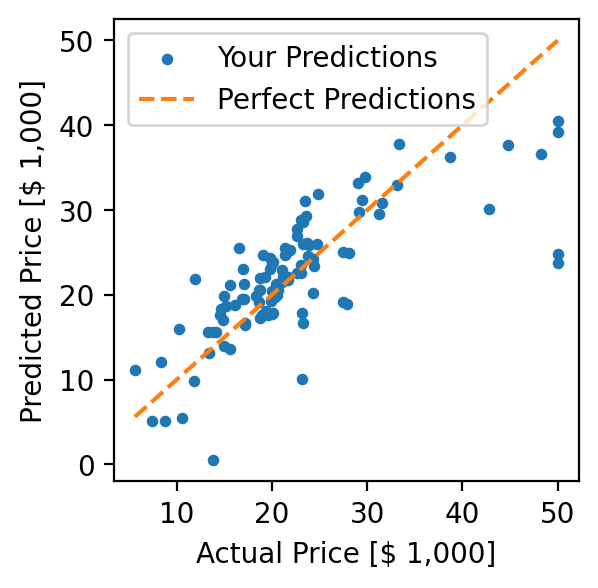

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3,3), dpi=200)

ax.scatter(y_test, y_prediction, color='C0', s = 10, label='Your Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='C1', linestyle = '--', label = "Perfect Predictions")
ax.set_xlabel('Actual Price [$ 1,000]')
ax.set_ylabel('Predicted Price [$ 1,000]')
ax.legend() 
plt.show()


#### Evaluating the fit: mean squared error (MSE)

How good are these predictions? The simplest score is the **mean squared
error** — the average squared gap between the predicted and true values, lower
is better:

$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}\big(y_i - \hat y_i\big)^2$$

(We'll meet more evaluation metrics in the Evaluation section further below.)

In [16]:
# The residuals e = y - X(beta hat) are the very thing the MSE objective averages.
mse_train = np.mean((y_train - X_train @ coefficients) ** 2)
mse_test  = np.mean((y_test  - y_prediction) ** 2)
print(f"MSE on the training set: {mse_train:.2f}")
print(f"MSE on the test set:     {mse_test:.2f}")

MSE on the training set: 19.72
MSE on the test set:     34.36


#### Another view of the same fit: maximum likelihood (MLE)

So far, fitting was pure geometry: pick $\beta$ to make the squared error small.
There is a second, **data-focused** view. Suppose the data really were generated
as $y_i = x_i^T \beta + \epsilon_i$ with Gaussian noise
$\epsilon_i \sim \mathcal{N}(0, \sigma^2)$. Then a natural way to pick $\beta$ is
**maximum likelihood (MLE)**: choose the coefficients that make the observed
data most probable.

For linear regression the two views coincide: maximizing the Gaussian
likelihood turns out to be the same as minimizing the squared error, and the
MSE is just the OLS objective divided by $n$
($\mathrm{MSE}(\beta) = \tfrac{1}{n}S(\beta)$, and a constant factor doesn't move the
minimum). So

$$\text{OLS} \;=\; \text{minimizing MSE} \;=\; \text{MLE}$$

— and the Gaussian assumption behind the MLE view is exactly what the residual
check below examines.

The MLE assumption in one picture — every observation is a draw from a Gaussian centred on the line:

<img src="https://raw.githubusercontent.com/uoft-ml-bootcamp/tutorials/main/02-supervised-learning/regression-and-svm/images/mle-gaussian-assumption.png" width="640" alt="mle-gaussian-assumption">

#### Checking the claim: OLS vs. MLE

We claimed OLS and MLE are the same estimator. Two steps:
**(i)** *train* the model by maximizing the Gaussian log-likelihood with a
numerical optimizer (no normal equation involved), then
**(ii)** *evaluate* it exactly the way we evaluated OLS and compare.

In [17]:
from scipy.optimize import minimize

# (i) TRAIN by MLE.
# Negative log-likelihood of the data under y_i ~ N(x_i'beta, sigma^2);
# the optimizer searches over the coefficients beta AND log(sigma) jointly.
def negative_log_likelihood(params):
    b, log_sigma = params[:-1], params[-1]
    sigma2 = np.exp(2 * log_sigma)
    residuals = y_train - X_train @ b
    n = len(y_train)
    return 0.5 * n * np.log(2 * np.pi * sigma2) + np.sum(residuals**2) / (2 * sigma2)

start = np.zeros(X_train.shape[1] + 1)
start[-1] = np.log(y_train.std())          # a reasonable initial guess for sigma
fit = minimize(negative_log_likelihood, start, method='BFGS',
               options={'maxiter': 20000})

mle_coefficients = fit.x[:-1]

print(f"negative log-likelihood at start          : {negative_log_likelihood(start):9.1f}")
print(f"negative log-likelihood after training    : {fit.fun:9.1f}   ({fit.nit} optimizer steps)")
print("-> training works: the optimizer drove the NLL down (likelihood up)")

negative log-likelihood at start          :    2684.0
negative log-likelihood after training    :    1175.5   (45 optimizer steps)
-> training works: the optimizer drove the NLL down (likelihood up)


**(ii) Evaluate** the MLE fit with the same tools we used for OLS — the
coefficients and the test predictions come out identical:

max |OLS - MLE| coefficient difference: 9.63e-05


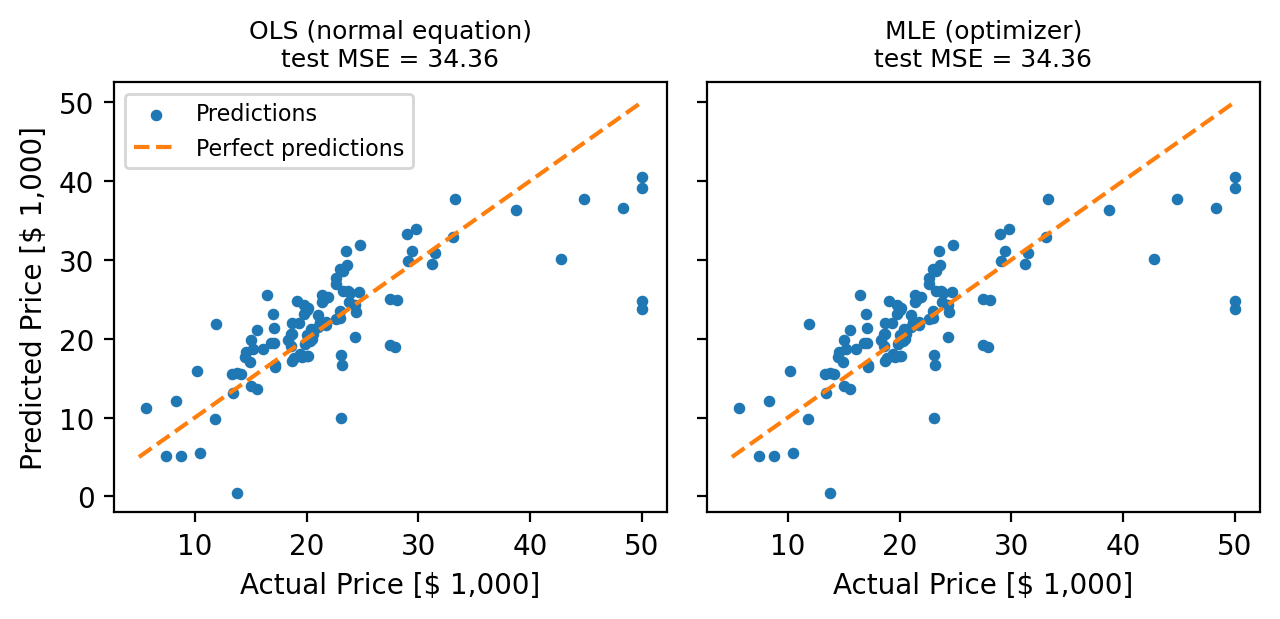

In [18]:
print("max |OLS - MLE| coefficient difference:",
      f"{np.abs(coefficients - mle_coefficients).max():.2e}")

# Predict the test set with each estimate and plot them side by side.
y_prediction_mle = X_test @ mle_coefficients
mse_test_mle = np.mean((y_test - y_prediction_mle) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2), dpi=200, sharex=True, sharey=True)
for ax, name, y_pred, mse in [
    (axes[0], 'OLS (normal equation)', y_prediction,     mse_test),
    (axes[1], 'MLE (optimizer)',       y_prediction_mle, mse_test_mle),
]:
    ax.scatter(y_test, y_pred, color='C0', s=10, label='Predictions')
    lims = [y_train.min(), y_train.max()]
    ax.plot(lims, lims, color='C1', linestyle='--', label='Perfect predictions')
    ax.set_xlabel('Actual Price [$ 1,000]')
    ax.set_title(f'{name}\ntest MSE = {mse:.2f}', fontsize=9)
axes[0].set_ylabel('Predicted Price [$ 1,000]')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Additional Task | Residual check — do the residuals look Gaussian?

The MLE view we just used **assumes Gaussian residuals** — that assumption is
precisely what made "maximize the likelihood" the same as "minimize the MSE".
OLS itself fits the line without any normality assumption, but two things do
rest on it: the MLE equivalence above, and the usual *inference* built on top
of OLS (confidence intervals and p-values for the coefficients). Roughly-normal,
zero-centred residuals are also a sign the linear model captured the structure
in the data. So let's actually check the assumption — two visual checks plus
one test:

- **Histogram** of the residuals — should be bell-shaped and centred on 0.
- **Q–Q plot** — residual quantiles vs. normal quantiles; if the residuals are normal the points lie on the diagonal. Curved tails (an S-shape) signal skew or heavy tails.
- **Shapiro–Wilk test** — null hypothesis "residuals are normal"; a p-value below 0.05 means we reject normality.

First, the **ideal picture**: residuals drawn from a *true* Gaussian (with the
same spread as our model's errors). This is what the checks should look like if
the Gaussian assumption is valid — bell-shaped histogram, Q–Q points on the
diagonal, Shapiro–Wilk $p > 0.05$.

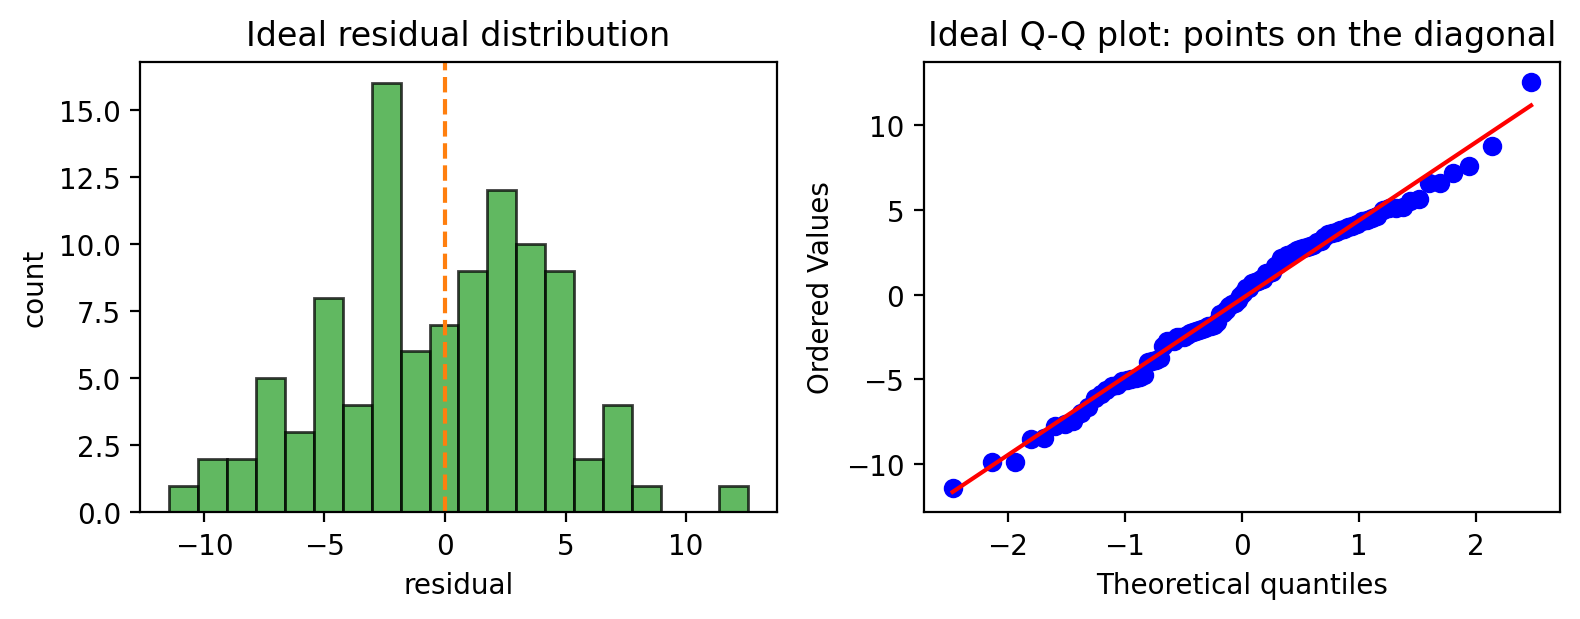

Shapiro-Wilk on ideal residuals:  W = 0.9892,  p = 0.5893
-> p > 0.05: consistent with normality, as expected


In [19]:
from scipy import stats

# Residuals as they WOULD look if the Gaussian assumption were exactly true:
# a normal sample with the same size and spread as our model's test errors.
rng = np.random.default_rng(42)
ideal_residuals = rng.normal(0, np.sqrt(mse_test), size=len(y_test))

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), dpi=200)

axes[0].hist(ideal_residuals, bins=20, edgecolor='k', alpha=0.75, color='C2')
axes[0].axvline(0, color='C1', linestyle='--')
axes[0].set_title("Ideal residual distribution")
axes[0].set_xlabel("residual")
axes[0].set_ylabel("count")

stats.probplot(ideal_residuals, dist="norm", plot=axes[1])
axes[1].set_title("Ideal Q-Q plot: points on the diagonal")

plt.tight_layout()
plt.show()

W, p = stats.shapiro(ideal_residuals)
print(f"Shapiro-Wilk on ideal residuals:  W = {W:.4f},  p = {p:.4f}")
print("-> p > 0.05: consistent with normality, as expected")

Now the same checks on **our** residuals — compare against the ideal picture above.

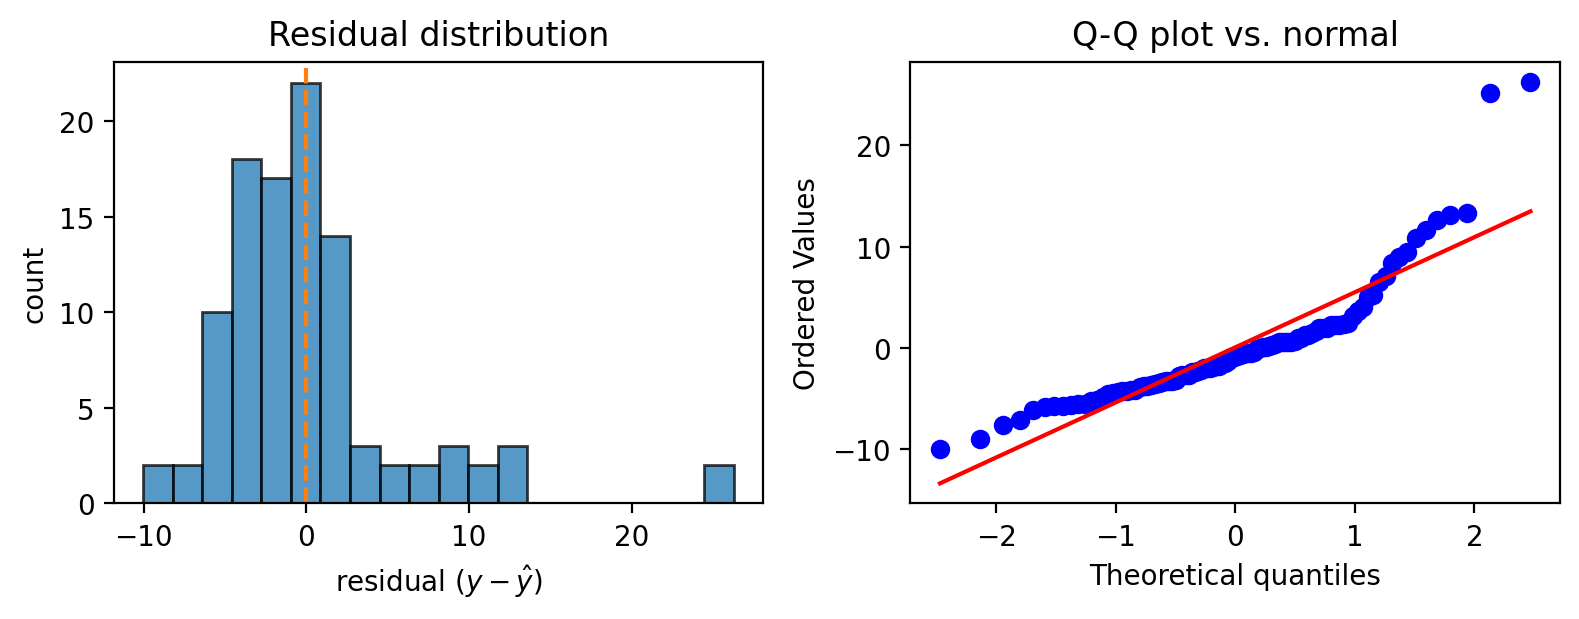

Shapiro-Wilk:  W = 0.8342,  p = 0.0000
-> reject normality at 5%: residuals are NOT Gaussian (skewed / heavy-tailed)


In [20]:
from scipy import stats
import matplotlib.pyplot as plt

# residuals on the test set (actual - predicted)
residuals = y_test - y_prediction

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2), dpi=200)

# (1) histogram - bell-shaped and centred on 0 if residuals are Gaussian
axes[0].hist(residuals, bins=20, edgecolor='k', alpha=0.75, color='C0')
axes[0].axvline(0, color='C1', linestyle='--')
axes[0].set_title("Residual distribution")
axes[0].set_xlabel(r"residual ($y - \hat{y}$)")
axes[0].set_ylabel("count")

# (2) Q-Q plot - points on the line => residuals match a normal distribution
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs. normal")

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test (H0: residuals are normal)
W, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk:  W = {W:.4f},  p = {p:.4f}")
print("-> cannot reject normality (residuals look Gaussian)" if p > 0.05
      else "-> reject normality at 5%: residuals are NOT Gaussian (skewed / heavy-tailed)")

For the Boston test set the residuals are **not** Gaussian — the Q–Q plot bends up at the right tail and Shapiro–Wilk rejects normality ($p \approx 0$, right-skewed). The model badly **under-predicts a handful of expensive houses** (the long right tail), partly because `medv` is capped at 50 in this dataset.

This doesn't invalidate the point predictions, but it warns that the coefficients' p-values / confidence intervals shouldn't be taken at face value. Common fixes: model $\log(\text{medv})$, add non-linear features, or use a more flexible model.

#### Evaluation
To evaluate the accuracy of a linear regression model, there are many metrics and techniques. 

- One common method is the Mean Squared Error (MSE). It calculate the average squared difference between the predicted values and the actual values of the target variable. The lower the MSE, the better the model fits the data.

- Additional metrics include the **Mean Error (ME)**, the average signed residual that captures the model's *bias*, and the **Mean Absolute Error (MAE)**, the average absolute residual.
- The **Root Mean Squared Error (RMSE)** is the square root of the MSE (back in the target's units), while the **CVRMSE** (Coefficient of Variation of the RMSE) rescales it by the mean target to give a unit-free percentage.

<!-- <img src="https://raw.githubusercontent.com/MLcmore2023/MLcmore2023/main/.images/linear_regression6.png" alt="image" width=60%> -->


$$\mathrm{MSE} = \underbrace{\frac{1}{n}\sum_{i=1}^{n}}_{\textbf{M}\text{ean}} \underbrace{\left(Y_i - \hat{Y}_i\right)^{2}}_{\textbf{S}\text{quared }\textbf{E}\text{rror}}$$


**Mean Error (ME)** — the average *signed* residual. It measures the model's **bias**; a positive value means the model under-predicts on average:

$$\mathrm{ME} = \frac{1}{n}\sum_{i=1}^{n}\left(Y_i - \hat{Y}_i\right)$$

**Mean Absolute Error (MAE)** — the average magnitude of the residuals:

$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n}\left|Y_i - \hat{Y}_i\right|$$

**Root Mean Squared Error (RMSE)** — the square root of the MSE, back in the units of $Y$:

$$\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(Y_i - \hat{Y}_i\right)^{2}} $$

**Coefficient of Variation of the RMSE (CVRMSE)** — the RMSE expressed as a percentage of the mean observed value $\bar{Y}$, which makes it unit-free and comparable across datasets:

$$\mathrm{CVRMSE} = \frac{\sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(Y_i - \hat{Y}_i\right)^{2}}}{\bar{Y}}\times 100\%, \qquad \bar{Y} = \frac{1}{n}\sum_{i=1}^{n} Y_i$$


In [21]:
# Compute all evaluation metrics from the test-set residuals (numpy only)
residuals = y_test - y_prediction

ME     = np.mean(residuals)              # Mean Error  (bias: + => model under-predicts)
MAE    = np.mean(np.abs(residuals))      # Mean Absolute Error
MSE    = np.mean(residuals ** 2)         # Mean Squared Error
RMSE   = np.sqrt(MSE)                    # Root Mean Squared Error

print(f"Mean Error (ME) : {ME:8.4f}")
print(f"MAE             : {MAE:8.4f}")
print(f"MSE             : {MSE:8.4f}")
print(f"RMSE            : {RMSE:8.4f}")

Mean Error (ME) :   0.0651
MAE             :   3.9529
MSE             :  34.3644
RMSE            :   5.8621


#### Interpreting the metrics

The target `medv` is a price in **thousands of dollars** (mean ≈ \$22.5k), so every error below is in \$1,000 units.

- **ME ≈ 0.07** — the average *signed* error is ~0, so the model is essentially **unbiased** (no systematic over/under-prediction). But ME hides magnitude: large + and − errors cancel, so a small ME alone never means "accurate".
- **MAE ≈ 3.95** — the typical prediction is off by about **\$3,950**. Same units as the target → the number to quote to a non-technical audience.
- **RMSE ≈ 5.86** — a **\$5,860** typical error. It **squares** the residuals, **RMSE is far more sensitive to extreme errors (outliers) than MAE**. Here RMSE ≫ MAE, flagging a few **big misses** — consistent with the skewed residuals above.
- **MSE ≈ 34.4** — RMSE squared, in \$1,000² units → **no direct real-world meaning**. Use it as the training objective and for model comparison, not for reporting.

### Exercise
1. Imagine you deploy this trained model as a housing-price calculator website. Does the storage size of the model (the file the server must keep in order to compute a prediction) depend on the number of houses in your training data? Why or why not?

2. How many numbers are there in the `coefficients` array? Hint: our original dataset have 13 features (13 input variables), but two of them are colinear.

3. Predict the price of the house `Hurley_St_375` below.

4. Write code for calculating the CVRMSE.

In [22]:
Hurley_St_375 = pd.DataFrame(
    [{  'crim': 1.2324700000000002,
        'zn': 0.0,
        'indus': 8.14,
        'chas': 0,
        'nox': 0.538,
        'rm': 6.142,
        'age': 91.7,
        'dis': 3.9769,
        'rad': 4,
        'tax': 307.0,
        'ptratio': 21.0,
        'b': 396.9,
        'lstat': 18.72,
        'medv': 15.2,
        }])
display(Hurley_St_375)

#code here
price = None #replace this with code

print("Hurley_St_375 should costs about",price,"thousand US dollars")

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,1.23247,0.0,8.14,0,0.538,6.142,91.7,3.9769,4,307.0,21.0,396.9,18.72,15.2


Hurley_St_375 should costs about None thousand US dollars


In [23]:
# Align Hurley_St_375 to the training feature layout: add the intercept column,
# rename 'black' -> 'b' (the name used in the dataset), then select and reorder the
# columns to match X (this also drops the unused 'tax' and 'medv' columns).
h = Hurley_St_375.copy()
h.insert(0, 'intercept', 1)
h = h[dataset_step2.columns]   # medv was already split off into y earlier
price = float((h.values @ coefficients)[0])  # [0] -> take the single scalar prediction
print("Hurley_St_375 should cost about", round(price, 2), "thousand US dollars")

Hurley_St_375 should cost about 15.95 thousand US dollars


In [24]:
#exercise: CVRMSE code here
rmse = np.sqrt(np.mean((y_test - y_prediction) ** 2))
cvrmse = rmse / np.mean(y_test) * 100   # RMSE as a percentage of the mean observed value
print(f"CVRMSE: {cvrmse:.2f} %")

CVRMSE: 26.38 %


### Reference
- https://online.stat.psu.edu/stat462/node/132/
- https://online.stat.psu.edu/stat462/node/177/